In [2]:
import astropy.units as u
import astropy.constants as c
from astropy.io import fits
from astropy.stats import gaussian_fwhm_to_sigma
import matplotlib.pyplot as plt
import numpy as np
import os
from astropy.cosmology import Planck18 as cosmo
from src.gen_gaussian_realizations import gaussian_random_field_3d
from src.map_power_spectrum import *
import datetime

import matplotlib.lines as mlines
import matplotlib.patches as mpatches

from src.load_TIM_noise import *
%matplotlib widget

In [3]:
CII_freq = (c.c *u.m/u.s/ (157.7 * u.um)).to(u.GHz)

1.5158941222080318e-07 W s(1/2) / (sr m2) 1.4978357741515071e-07 W s(1/2) / (sr m2)
3.839229827226562e-07 W s(1/2) / (sr m2) 3.8433570749038465e-07 W s(1/2) / (sr m2)


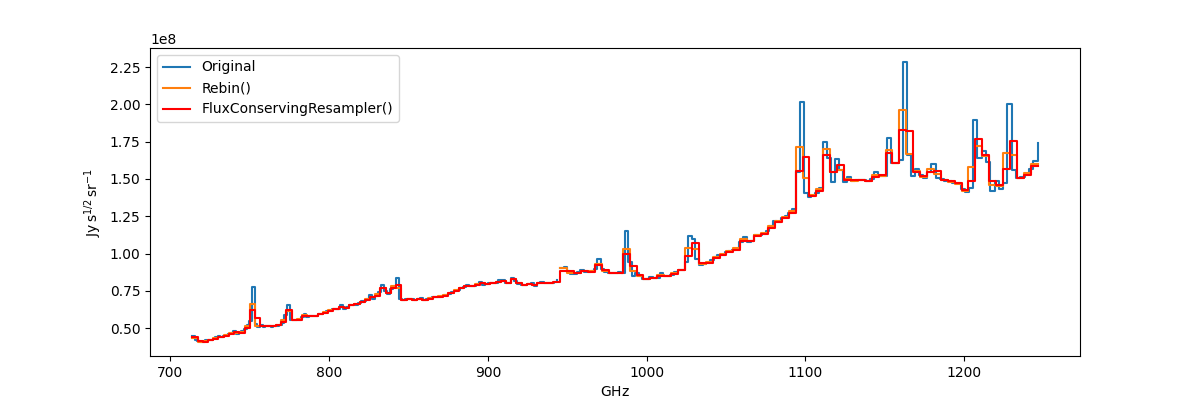

In [4]:
#Evan's original method to load Frank's noise model
#------------------------------------------------------------------------------------------
nus_model_lw, nei_model_lw = TIM_NEI_model(which='LW', path='src/')
nus_model_sw, nei_model_sw = TIM_NEI_model(which='SW', path='src/')
nus_model_sw = nus_model_sw.to(u.GHz)
nus_model_lw = nus_model_lw.to(u.GHz)

dnu_sw = (nus_model_sw / 250).to(u.GHz)
dnu_lw = (nus_model_lw / 250).to(u.GHz)

nus_sw = np.arange(nus_model_sw[0].value, nus_model_sw[-1].value, dnu_sw.mean().value) * u.GHz
nus_lw = np.arange(nus_model_lw[0].value, nus_model_lw[-1].value, dnu_lw.mean().value) * u.GHz

dnu_sw = (nus_sw / 250).to(u.GHz)
dnu_lw = (nus_lw / 250).to(u.GHz)

fig, ax = plt.subplots(figsize=(12,4))
ax.step(nus_model_sw, nei_model_sw, color='C0', where='post')
ax.step(nus_model_lw, nei_model_lw, color='C0', where='post', label='Original')

_, nei_sw = rebin(nus_model_sw, nei_model_sw, nus_sw)
_, nei_lw = rebin(nus_model_lw, nei_model_lw, nus_lw)
ax.step(nus_sw, nei_sw, color='C1', where='post', label='Rebin()')
ax.step(nus_lw, nei_lw, color='C1', where='post')
#------------------------------------------------------------------------------------------


#----------------------------------------------------------------------------------------
#Using FluxConservingResampler

frequencies = np.concatenate((nus_lw,nus_sw))
dnu         =  np.concatenate((dnu_lw,dnu_sw))

_, NEI = set_TIM_noise(frequencies)

def fill_nan_left(arr):
    arr = arr.copy()
    mask = np.isnan(arr)
    idx = np.where(~mask, np.arange(len(arr)), 0)
    np.maximum.accumulate(idx, out=idx)
    return arr[idx]
NEI = fill_nan_left(NEI)

ax.step(frequencies, NEI,c='r',where='post', label='FluxConservingResampler()')
ax.legend()
#------------------------------------------------------------------------------------------

# Sanity check:
print(
    np.trapz(nei_model_lw, nus_model_lw).to(u.W * u.s**.5 / u.m**2 / u.sr), 
    np.trapz(nei_lw, nus_lw).to(u.W * u.s**.5 / u.m**2 / u.sr)
)
print(
    np.trapz(nei_model_sw, nus_model_sw).to(u.W * u.s**.5 / u.m**2 / u.sr), 
    np.trapz(nei_sw, nus_sw).to(u.W * u.s**.5 / u.m**2 / u.sr)
)


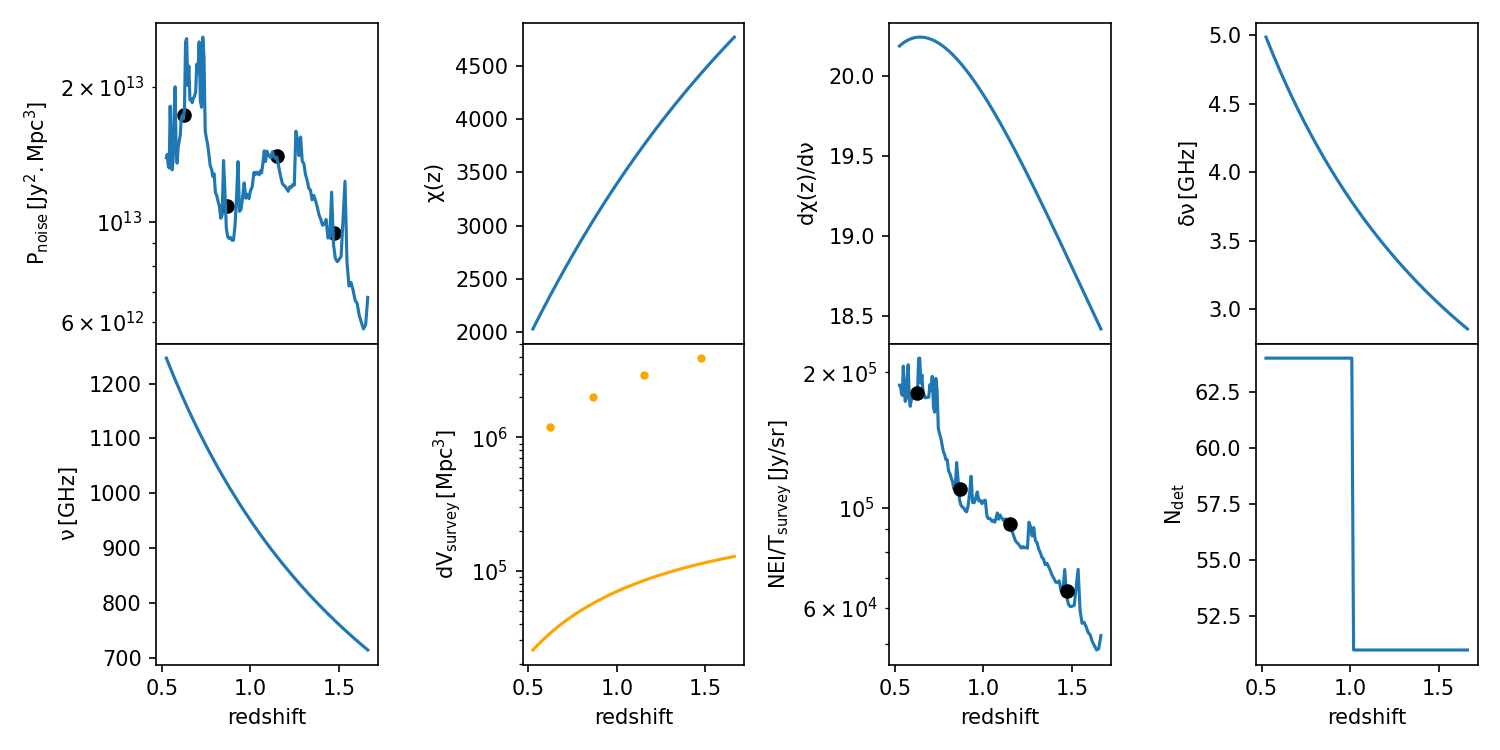

In [5]:
#Compute P_noise for the 4 redshift bins of TIM

#---------------------------------------------------------------------------
#TIM survey specs
Omega_survey = 1 #area of the survey in deg2
Omega_survey *= (np.pi/180)**2 #convert it to steradiants
t_survey = 200 * 3600 *u.s #survey integration time in seconds
NEI_int = NEI/np.sqrt(t_survey) #Noise level in Jy/sr
#---------------------------------------------------------------------------

#---------------------------------------------------------------------------
#Create the number of detectors per frequency channel vector
Ndets_per_zbin = (51, 51, 64, 64)
#Cut the frequency vector into 4 bins
ind_bins = np.array_split(np.arange(len(frequencies)), 4)
Ndets_per_channel = np.zeros(len(frequencies))
for ibin, N in zip(ind_bins, Ndets_per_zbin): Ndets_per_channel[ibin] = N
#---------------------------------------------------------------------------

#---------------------------------------------------------------------------
#Compute redshifts and redshifts widths
redshifts = CII_freq / frequencies -1 
dz = redshifts * dnu / frequencies
redshifts_min = redshifts - dz/2
redshifts_max = redshifts + dz/2
#---------------------------------------------------------------------------

#---------------------------------------------------------------------------
#Compute volume of Universe probed by each channel 
Dc_max = cosmo.comoving_distance(redshifts_max)
Dc_min = cosmo.comoving_distance(redshifts_min)
chi = cosmo.comoving_distance(redshifts)
dchi_over_dnu =  (c.c*u.m/u.s*1e-3) / cosmo.H(redshifts) * (1+redshifts)**2 / CII_freq * dnu
dV = Omega_survey * chi**2 * (c.c*u.m/u.s*1e-3) / cosmo.H(redshifts) * (1+redshifts)**2 * dnu / CII_freq
#---------------------------------------------------------------------------

#Noise per channel
P_n = NEI_int**2 / Ndets_per_channel * dV 

#---------------------------------------------------------------------------
# A 2nd method is to compute a noise average per redshift bin 
# (i.e, in several frequency channels), instead of per frequency channel
NEI_per_bin = []
redshift_per_bin = []
nu_per_bin = []
numin_per_bin = []
numax_per_bin = []
dV_per_bin = []
channels_per_bin = []
P_n_per_bin = []
volumes_per_bin = []

for ibin, N in zip(ind_bins, Ndets_per_zbin):

    NEI_per_bin.append( np.nanmedian(NEI_int[ibin]) )
    redshift_per_bin.append(redshifts[ibin].mean())
    nu_per_bin.append(frequencies[ibin].mean())
    numin_per_bin.append(frequencies[ibin].min())
    numax_per_bin.append(frequencies[ibin].max())
    dV_per_bin.append(np.sum(dV[ibin]))
    channels_per_bin.append(len(ibin))
    P_n_per_bin.append( np.nanmedian(NEI_int[ibin])**2 * np.sum(dV[ibin]) / N / len(ibin) )
#---------------------------------------------------------------------------

#Comparison plot

fig, axs = plt.subplots(2,4,figsize=(10,5), dpi=150, sharex = True)
for i in range(4): axs[1,i].set_xlabel("redshift")
axa,axc,axd, axg,axh,axi,axj, axb = axs[0,0], axs[0,1], axs[0,2], axs[0,3], axs[1,0], axs[1,1], axs[1,2], axs[1,3]

axb.set_ylabel("$\\rm N_{det}$")
axc.set_ylabel("$\\rm \\chi(z)$")
axd.set_ylabel("$\\rm d\\chi(z)/d\\nu$")
axg.set_ylabel("$\\rm \\delta\\nu \,[GHz]$")
axh.set_ylabel("$\\rm \\nu \,[GHz]$")
axi.set_ylabel("$\\rm dV_{survey} \,[Mpc^3]$")

axj.set_ylabel("$\\rm NEI/T_{survey}\,[Jy/sr]$")
axj.plot(redshifts,NEI_int); axj.set_yscale('log')
for z, n in zip(redshift_per_bin, NEI_per_bin): axj.plot(z, n, 'ok')

axa.set_ylabel("$\\rm P_{noise}\, [Jy^2.Mpc^3]$")
for z, n in zip(redshift_per_bin, P_n_per_bin): axa.plot(z,n, 'ok'); axa.set_yscale('log')
axa.plot(redshifts,P_n); axa.set_yscale('log')

axb.plot(redshifts, Ndets_per_channel)
axc.plot(redshifts, chi)
axd.plot(redshifts, dchi_over_dnu)
axg.plot(redshifts, dnu)
axh.plot(redshifts, frequencies)
#axh.plot(redshift_per_bin,nu_per_bin,'ok')
axi.plot(redshifts, dV, color='orange'); axi.set_yscale('log')
for z, n in zip(redshift_per_bin, volumes_per_bin): axi.plot(z, n, 'ok')
for z, n in zip(redshift_per_bin, dV_per_bin): axi.plot(z, n, '.',color='orange')
fig.tight_layout()
fig.subplots_adjust(hspace=0)

save noise_cube_z1.47.fits
save noise_cube_z1.15.fits
save noise_cube_z0.87.fits
save noise_cube_z0.62.fits
save chromatic_noise_cube_z0.62.fits
save chromatic_noise_cube_z0.87.fits
save chromatic_noise_cube_z1.15.fits
save chromatic_noise_cube_z1.47.fits


(100000000000.0, 100000000000000.0)

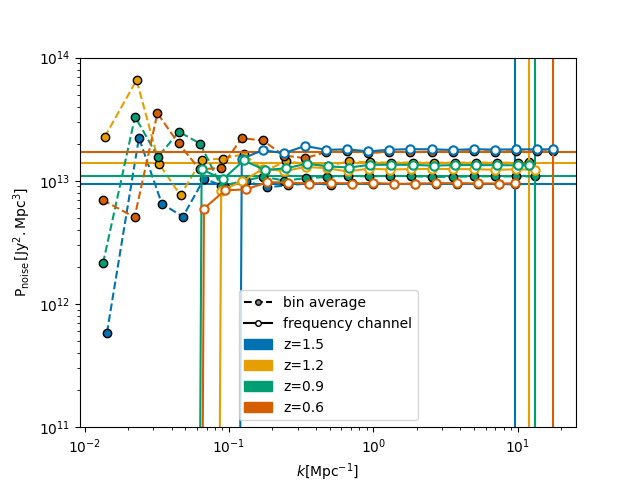

In [20]:
#Now we can create the gaussian maps

#-------------------------------------------
#Gaussian maps specifications:
npix = 250
k = np.logspace(np.log10(7e-3),np.log10(12))
#resolution in Mpc along the los
Delta_Dc_list = (cst.c*1e-3*(1+redshifts) / cosmo.H(redshifts) * dnu / frequencies ).value
#resolution along the transverse direction to the los
res = (20*u.arcsec).to(u.rad)
len_pix_list  = (cosmo.comoving_transverse_distance(redshifts) * res ).value
#k vector in Mpc-1
k = np.logspace(np.log10(1e-4),np.log10(1e2))
#-------------------------------------------

#Comparison plot
plt.figure()
patchs = []
patch = mlines.Line2D( [], [], ls='--', marker='o',  markersize=4,  markerfacecolor='grey',  markeredgecolor='k',  color='k',  label='bin average'); patchs.append(patch)    
patch = mlines.Line2D( [], [], ls='solid', marker='o',  markersize=4,  markerfacecolor='white',  markeredgecolor='k',  color='k',  label='frequency channel'); patchs.append(patch)  

#1) Cubes with noise averaged per redshift bin
#For each redshift bin...
for i, (P_noise,ibin,c) in enumerate(zip(P_n_per_bin,ind_bins, ["#0072B2", "#E69F00", "#009E73", "#D55E00"])):

    plt.axhline(P_noise, color=c)
    patch = mpatches.Patch(color=c, label= f"z={z.mean():.1f}"); patchs.append(patch)
             
    #Select the specs of this redshift bin
    #-------------------------------------------
    z = redshifts[ibin]
    chi = cosmo.comoving_transverse_distance(z)
    dnu_bin = dnu[ibin]
    freqs_bin = frequencies[ibin]
    nu_min = numin_per_bin[i]
    nz = channels_per_bin[i]
    Delta_Dc = np.mean(Delta_Dc_list[ibin])
    len_pix  = np.mean(len_pix_list[ibin])
    #-------------------------------------------
    
    #-------------------------------------------
    #Generate the cube
    cube, pkarray = gaussian_random_field_3d(k, P_noise.value*np.ones(len(k)), npix, npix, nz, len_pix, len_pix, Delta_Dc )
    #-------------------------------------------


    #--------------------------------------------------------------------
    #Demo to save the cube as .fits
    f= fits.PrimaryHDU(cube)
    hdu = fits.HDUList([f])
    hdr = hdu[0].header
    hdr.set("cube")
    hdr.set("Datas")
    hdr["BITPIX"] = ("64", "array data type")
    hdr["BUNIT"] = 'Jy/sr'
    hdr["DATE"] = (str(datetime.datetime.now()), "date of the creation")
    for i, vox_size in enumerate(( len_pix, len_pix, Delta_Dc)):

        vox_size = u.Quantity(vox_size, u.Mpc)  # FORCE unit here
        hdr[f"CDELT{int(i+1)}"] = vox_size.to(u.Mpc).value
        hdr[f"CUNIT{int(i+1)}"] = 'Mpc'
        #hdr[f"NAXIS{int(i+1)}"] = npix
    output_name = f'noise_cube_z{z.mean():.2f}.fits'
    hdu.writeto(output_name, overwrite=True)
    print('save '+output_name)
    hdu.close()
    #--------------------------------------------------------------------

    #--------------------------------------------------------------------
    #Measure the 3D power spectrum of this cube
    pk3d = threedim_power_spectrum_for_comoving_cubes( cube, Delta_Dc, len_pix, len_pix, delta_k_over_k_perp=0.4, delta_k_over_k_par=0.4)
    P2D_avg, Nmodes, kpar_edges_out, kperp_edges_out, P1D_avg, kshpere_edges_out, Nmodes1d, ksphere_out, kmap_3d, k_z_3d = pk3d.p3()
    #plt.loglog(ksphere_out, P1D_avg, 'o--', color=c)
    plt.loglog(ksphere_out, P1D_avg, 'o--',  color=c, markerfacecolor=c,  markeredgecolor='k', markeredgewidth=1)
    plt.axvline(ksphere_out.max(), color=c)
    #--------------------------------------------------------------------
    
#2) Generate a cube with noise per frequency channel
#For each redshift bin...
for i, (ibin,c) in enumerate(zip(reversed(ind_bins), ["#0072B2", "#E69F00", "#009E73", "#D55E00"])):


    #-------------------------------------------
    P_bin = P_n[ibin]
    len_pix_bin = len_pix_list[ibin]
    Delta_Dc_bin = Delta_Dc_list[ibin]
    zmean = redshifts[ibin].mean()
    #-------------------------------------------

    #-------------------------------------------
    #Generate a noise slice for each frequency channel
    cube = []
    for P_noise, d, dz in zip(P_bin,len_pix_bin ,Delta_Dc_bin ):
        pk = P_noise*np.ones(len(k))
        slice, _ = gaussian_random_field_3d(k, pk, npix, npix, 1, d, d, dz )
        cube.append(slice)
    #Reshape the slices into a cube
    cube = np.asarray(cube)[:,0,:,:]
    #-------------------------------------------

    #-------------------------------------------
    pk3d = threedim_power_spectrum_for_comoving_cubes( cube, Delta_Dc_bin.mean(), len_pix_bin.mean(), len_pix_bin.mean(), delta_k_over_k_perp=0.4, delta_k_over_k_par=0.4)
    P2D_avg, Nmodes, kpar_edges_out, kperp_edges_out, P1D_avg, kshpere_edges_out, Nmodes1d, ksphere_out, kmap_3d, k_z_3d = pk3d.p3()
    #plt.loglog(ksphere_out, P1D_avg, '*--', color=c, alpha=0.5, label=f'z={zmean:.2f}')
    plt.loglog( ksphere_out,P1D_avg, '-o', color=c, markerfacecolor='white', markeredgecolor=c,    markeredgewidth=1.5)
    #-------------------------------------------

    #----------------------------------------------------------------------------------
    f = fits.PrimaryHDU(cube)
    hdu = fits.HDUList([f])
    hdr = hdu[0].header
    hdr.set("cube")
    hdr.set("Datas")
    hdr["BITPIX"] = ("64", "array data type")
    hdr["BUNIT"] = 'MJy/sr'
    hdr["DATE"] = (str(datetime.datetime.now()), "date of the creation")

    for i, vox_size in enumerate( (len_pix_bin.mean(), len_pix_bin.mean(), Delta_Dc_bin.mean())):
        vox_size = u.Quantity(vox_size, u.Mpc)  # FORCE unit here
        hdr[f"CDELT{int(i+1)}"] = vox_size.to(u.Mpc).value
        hdr[f"CUNIT{int(i+1)}"] = 'Mpc'
        #hdr[f"NAXIS{int(i+1)}"] = npix
    output_name = f'chromatic_noise_cube_z{redshifts[ibin].mean():.2f}.fits'
    hdu.writeto(output_name, overwrite=True)
    print('save '+output_name)
    hdu.close()
    #----------------------------------------------------------------------------------

plt.legend(handles=patchs)
plt.xscale('log')
plt.yscale('log')
plt.ylabel("$\\rm P_{noise}\, [Jy^2.Mpc^3]$")
plt.xlabel("$k \\rm [Mpc^{-1}]$")
plt.ylim(1e11,1e14)
